# Customer Segmentation - K-Means

In [541]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = 'data/Mall_Customers.csv'
raw_df = pd.read_csv(data_path)
df = raw_df.copy().drop(['CustomerID','Gender'], axis = 1)

## Examining Dataset

In [542]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB
None


## Pre-processing

In [543]:
X = df.to_numpy()


## K-Means Class

In [544]:
class KMeans():
    def __init__(self, k):
        self.k = k

    def fit(self, X):
        self.X = X
        iters = 200
        indices = np.random.choice(np.arange(len(X)), size = self.k, replace = False)
        centroids = X[indices]

        for _ in range(iters):
            #Assign
            diff = np.sqrt(((X[:,np.newaxis,:] - centroids)** 2).sum(axis = 2))
            labels = np.argmin(diff, axis = 1)
            
            #Update
            new_centroids = np.array([X[labels == i].mean(axis = 0) for i in range(self.k)])

            #Check convergence

            if np.array_equal(centroids, new_centroids):
                break

        self.centroids = new_centroids
        self.labels = labels        
                
    def inertia(self):
        self.wcss = np.sum([np.sum(np.square(self.X[self.labels==i] - self.centroids[i])) for i in range(self.k)])

        return self.wcss

    def plot(self):
        plt.figure(figsize = (12,5))
        plt.scatter(self.X[:, 1], self.X[:, 2], c=self.labels, cmap='tab10')
        plt.scatter(self.centroids[:, 1], self.centroids[:, 2], c='red', marker='*', s=300, zorder=5)
        plt.xlabel('Annual Income (k$)')
        plt.ylabel('Spending Score (1-100)')
        plt.title(f"K-Means (k={self.k})")
        plt.show()


        
    

## Analysis

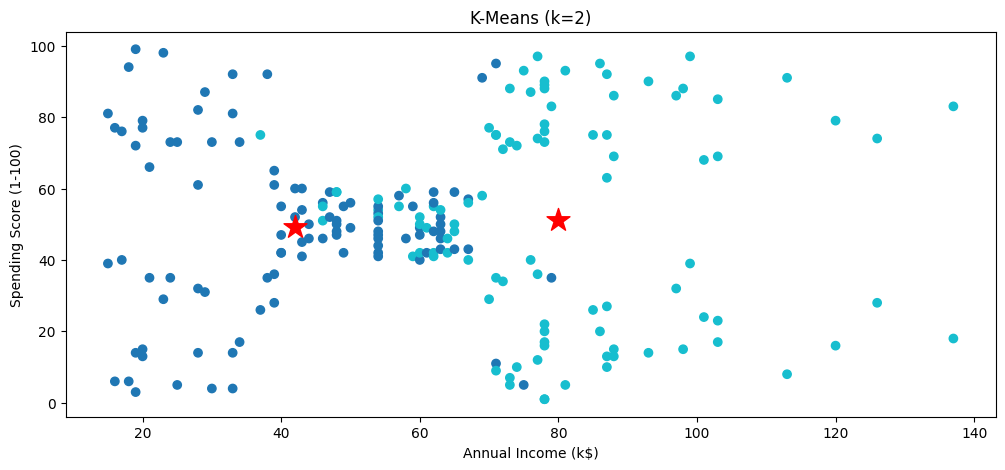

In [545]:
kmeantest = KMeans(2)
kmeantest.fit(X)
kmeantest.plot()

[np.float64(308812.78), np.float64(237902.3), np.float64(190458.8254750176), np.float64(168293.94862858378), np.float64(141819.83071428572), np.float64(145506.70776756248), np.float64(77843.84505155307), np.float64(99116.46382488479)]


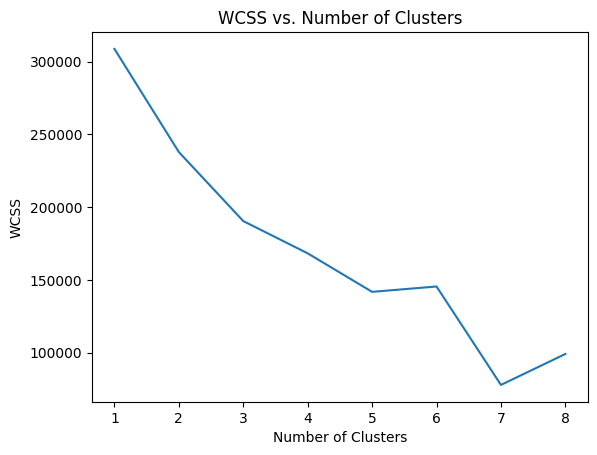

In [546]:
wcss_values = []
for i in range(1, 9):
    kmeans = KMeans(k=i)
    kmeans.fit(X)
    wcss = kmeans.inertia()
    wcss_values.append(wcss)

print(wcss_values)
plt.plot(range(1, 9), wcss_values)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('WCSS vs. Number of Clusters')
plt.show()